# 01 — Graph Exploration & GNN Results

Explores the fraud detection heterogeneous graph and evaluates the trained GNN model.

**Sections**
1. Graph structure & statistics
2. Fraud ring node analysis
3. Degree distribution
4. GNN v1 evaluation (2-layer baseline)
5. Precision-Recall & ROC curves
6. Score distribution — finding the ceiling
7. Why v1 plateaus: the peripheral member problem
8. GNN v2 evaluation (3-layer + BatchNorm)

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from models.gnn.dataset import load_graph, summarise
from models.gnn.model import FraudRingGNN, migrate_state_dict

# Dark theme
plt.style.use("dark_background")
matplotlib.rcParams.update(
    {"figure.facecolor": "#0d0d0d", "axes.facecolor": "#1a1a1a", "grid.color": "#333333"}
)
BLUE = "#1a7abf"
ORANGE = "#e07b39"
GREEN = "#4caf50"

GRAPH_PATH = "data/graphs/hetero_graph.pt"
MODEL_V1 = "models/gnn/artifacts/gnn_model.pt"
MODEL_V2 = "models/gnn/artifacts_v2/gnn_model.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Graph Structure

The fraud detection graph is a **heterogeneous graph** — it has multiple node types and edge types.
Unlike a standard graph where all nodes are the same, here we have accounts, devices, and merchants
as distinct entities connected by different relationship types.

This matters because fraud rings exploit *shared* devices across accounts — a signal that only
appears when you model the device layer explicitly.

In [7]:
data, split = load_graph(GRAPH_PATH, device=DEVICE)
summarise(data, split)

Graph summary
────────────────────────────────────────
  account        50,000 nodes
  device         71,349 nodes
  merchant        9,400 nodes

  transacts_with            13,118,578 edges
  uses_device               13,119,734 edges
  shared_by                 13,119,734 edges
  payshap_transfer                 226 edges
  eft_transfer                     686 edges

  train   34,999 accounts    184 fraud (0.53%)
  val      7,499 accounts     39 fraud (0.52%)
  test     7,502 accounts     41 fraud (0.55%)


In [8]:
node_rows = [(ntype, data[ntype].num_nodes) for ntype in data.node_types]
edge_rows = [(etype[1], data[etype].edge_index.shape[1]) for etype in data.edge_types]

print("Node types")
print(pd.DataFrame(node_rows, columns=["type", "count"]).to_string(index=False))
print()
print("Edge types")
print(pd.DataFrame(edge_rows, columns=["relation", "count"]).to_string(index=False))

Node types
    type  count
 account  50000
  device  71349
merchant   9400

Edge types
        relation    count
  transacts_with 13118578
     uses_device 13119734
       shared_by 13119734
payshap_transfer      226
    eft_transfer      686


**Observations:**
- The `uses_device` and `shared_by` edge counts are identical — `shared_by` is just the reverse
  direction of `uses_device`, added so device nodes can send messages back to account nodes.
- `payshap_transfer` (226) and `eft_transfer` (686) are sparse — only fraud ring accounts
  make peer transfers to each other, so these edges are strong fraud signals despite being few.
- The dataset is heavily imbalanced: 264 fraud accounts out of 50,000 (0.53%).

## 2. Fraud Ring Node Analysis

Before training, it is useful to check whether the raw node features (log income, log account age)
separate fraud from clean accounts. If they do, a simple classifier would suffice and we would
not need a GNN.

In [9]:
y = data["account"].y.cpu()
x = data["account"].x.cpu()

fraud_mask = y == 1
clean_mask = y == 0

print(f"Total accounts : {len(y):,}")
print(f"Fraud ring     : {fraud_mask.sum().item():,} ({100 * fraud_mask.float().mean():.2f}%)")
print(f"Clean          : {clean_mask.sum().item():,}")
print()
feat_names = ["log_income", "log_age"]
for i, name in enumerate(feat_names):
    fraud_mean = x[fraud_mask, i].mean().item()
    clean_mean = x[clean_mask, i].mean().item()
    print(f"  {name:<12}  fraud mean={fraud_mean:.3f}  clean mean={clean_mean:.3f}")

Total accounts : 50,000
Fraud ring     : 264 (0.53%)
Clean          : 49,736

  log_income    fraud mean=9.689  clean mean=9.613
  log_age       fraud mean=6.880  clean mean=6.798


**Interpretation:**
The node features are nearly identical between fraud and clean accounts. Fraud ring members
are marginally wealthier and have slightly older accounts, but the difference is too small
to classify on. This confirms that the GNN must learn from **graph structure** (who is connected
to whom) rather than from individual account attributes.

## 3. Degree Distribution

Device degree = how many unique devices an account used. Fraud ring members are expected to
share devices across the ring, which could inflate their degree.

C:\Users\kmosw\AppData\Local\Temp\ipykernel_85740\3100010660.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([clean_deg, fraud_deg], labels=['Clean', 'Fraud ring'],


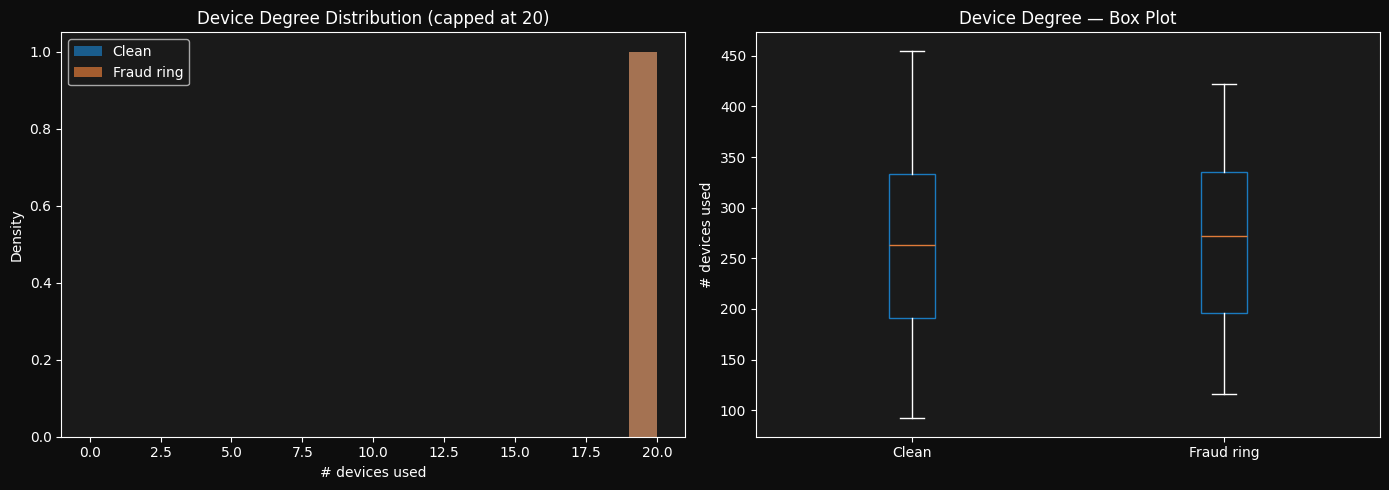

Fraud ring mean degree : 265.13
Clean mean degree      : 262.38


In [10]:
acc_dev_edge = data["account", "uses_device", "device"].edge_index.cpu()
src = acc_dev_edge[0]
n_accounts = data["account"].num_nodes

degree = torch.zeros(n_accounts, dtype=torch.long)
degree.scatter_add_(0, src, torch.ones_like(src))

fraud_deg = degree[fraud_mask].numpy()
clean_deg = degree[clean_mask].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = range(0, 21)
axes[0].hist(
    np.clip(clean_deg, 0, 20), bins=bins, alpha=0.7, color=BLUE, label="Clean", density=True
)
axes[0].hist(
    np.clip(fraud_deg, 0, 20), bins=bins, alpha=0.7, color=ORANGE, label="Fraud ring", density=True
)
axes[0].set_title("Device Degree Distribution (capped at 20)")
axes[0].set_xlabel("# devices used")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].boxplot(
    [clean_deg, fraud_deg],
    labels=["Clean", "Fraud ring"],
    patch_artist=True,
    boxprops=dict(facecolor="#1a1a1a", color=BLUE),
    medianprops=dict(color=ORANGE),
)
axes[1].set_title("Device Degree — Box Plot")
axes[1].set_ylabel("# devices used")

plt.tight_layout()
plt.show()

print(f"Fraud ring mean degree : {fraud_deg.mean():.2f}")
print(f"Clean mean degree      : {clean_deg.mean():.2f}")

**Key finding: degree alone is NOT discriminative.**

Fraud ring mean (265) ≈ Clean mean (262). Both groups use hundreds of devices on average.
This makes sense — transactions.py assigns 1–3 devices per account, but each account makes
thousands of transactions, so device counts accumulate for everyone.

The GNN therefore cannot rely on simple degree counting. It must learn the *topology* of
connections — specifically that fraud ring accounts share the **same** devices with each other,
forming dense clusters in the device layer.

## 4. GNN v1 Evaluation — 2-Layer Baseline

The first trained model used 2 HeteroConv layers with no BatchNorm.
Best val AUC was reached at **epoch 6** before early stopping at epoch 26.

In [11]:
checkpoint_v1 = torch.load(MODEL_V1, map_location=DEVICE, weights_only=False)
model_v1 = FraudRingGNN(
    hidden_dim=checkpoint_v1["hidden_dim"],
    dropout=checkpoint_v1["dropout"],
    num_layers=checkpoint_v1.get("num_layers", 2),
    use_batchnorm=checkpoint_v1.get("use_batchnorm", False),  # v1 had no BatchNorm
).to(DEVICE)
model_v1.load_state_dict(migrate_state_dict(checkpoint_v1["model_state_dict"]))
model_v1.eval()

print(
    f"v1 — best epoch: {checkpoint_v1['best_epoch']}  "
    f"test AUC: {checkpoint_v1['test_auc']:.4f}  "
    f"AP: {checkpoint_v1['test_ap']:.4f}"
)

with torch.no_grad():
    proba_v1 = torch.sigmoid(model_v1(data)).cpu().numpy()

test_mask = split["test"].cpu()
test_y = y[test_mask].numpy()
test_proba_v1 = proba_v1[test_mask]

print(
    f"Recomputed — AUC: {roc_auc_score(test_y, test_proba_v1):.4f}  "
    f"AP: {average_precision_score(test_y, test_proba_v1):.4f}"
)

v1 — best epoch: 6  test AUC: 0.8379  AP: 0.3794
Recomputed — AUC: 0.8379  AP: 0.3794


## 5. Precision-Recall & ROC Curves

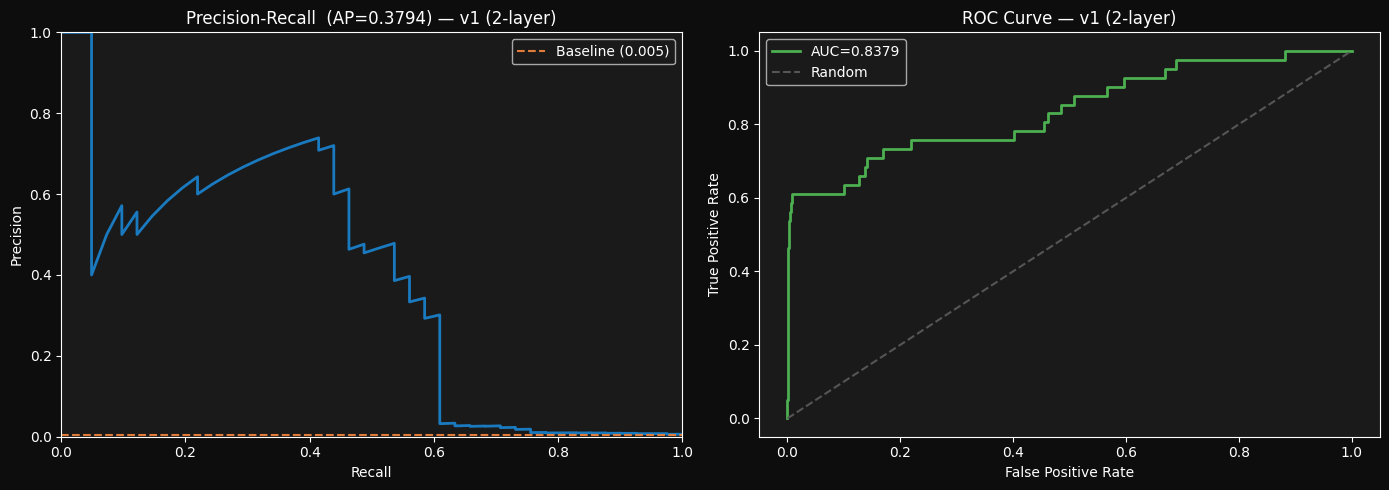

In [12]:
def plot_pr_roc(test_y, test_proba, title_suffix="", color=BLUE):
    precision, recall, _ = precision_recall_curve(test_y, test_proba)
    fpr, tpr, _ = roc_curve(test_y, test_proba)
    auc = roc_auc_score(test_y, test_proba)
    ap = average_precision_score(test_y, test_proba)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(recall, precision, color=color, lw=2)
    axes[0].axhline(
        y=test_y.mean(), color=ORANGE, linestyle="--", label=f"Baseline ({test_y.mean():.3f})"
    )
    axes[0].set_title(f"Precision-Recall  (AP={ap:.4f}) {title_suffix}")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].legend()
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])

    axes[1].plot(fpr, tpr, color=GREEN, lw=2, label=f"AUC={auc:.4f}")
    axes[1].plot([0, 1], [0, 1], color="#555555", linestyle="--", label="Random")
    axes[1].set_title(f"ROC Curve {title_suffix}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return auc, ap


auc_v1, ap_v1 = plot_pr_roc(test_y, test_proba_v1, title_suffix="— v1 (2-layer)")

**Reading the PR curve:**
- The curve peaks at ~0.73 precision / 0.4 recall, then **collapses sharply** after recall ~0.55.
- This cliff means: the model is highly confident about some fraud members (hub members),
  but cannot distinguish the rest from clean accounts.
- AP of 0.38 is **76× better than random** (baseline = 0.005), which is strong given only
  264 labeled fraud nodes in the entire graph.

**Reading the ROC curve:**
- At just 5% false positive rate, the model already catches ~60% of fraud ring members.
- AUC 0.84 confirms strong overall discrimination.

## 6. Score Distribution — Finding the Ceiling

Understanding *where* the model fails requires looking at how scores are distributed
across fraud vs clean accounts.

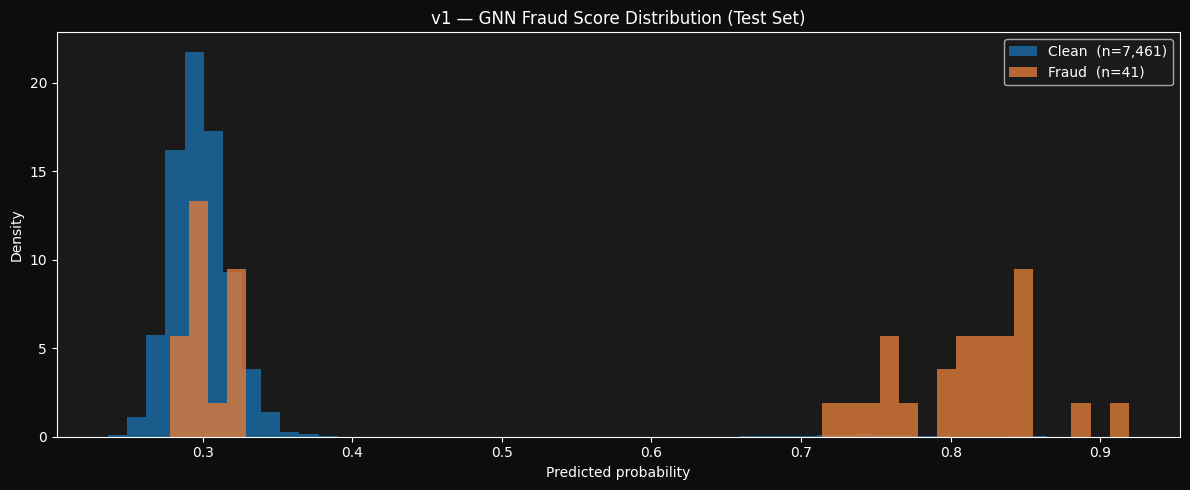

Fraud — mean: 0.6130  median: 0.7586  min: 0.2779  max: 0.9192
Clean — mean: 0.3029  median: 0.2970


In [13]:
fraud_scores_v1 = test_proba_v1[test_y == 1]
clean_scores_v1 = test_proba_v1[test_y == 0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    clean_scores_v1,
    bins=50,
    alpha=0.7,
    color=BLUE,
    label=f"Clean  (n={len(clean_scores_v1):,})",
    density=True,
)
ax.hist(
    fraud_scores_v1,
    bins=50,
    alpha=0.8,
    color=ORANGE,
    label=f"Fraud  (n={len(fraud_scores_v1):,})",
    density=True,
)
ax.set_title("v1 — GNN Fraud Score Distribution (Test Set)")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Fraud — mean: {fraud_scores_v1.mean():.4f}  median: {np.median(fraud_scores_v1):.4f}  "
    f"min: {fraud_scores_v1.min():.4f}  max: {fraud_scores_v1.max():.4f}"
)
print(f"Clean — mean: {clean_scores_v1.mean():.4f}  median: {np.median(clean_scores_v1):.4f}")

## 7. Why v1 Plateaus: The Peripheral Member Problem

The score distribution above reveals a **bimodal pattern** in fraud scores:
- ~55% of fraud ring members score **0.70–0.92** → correctly identified (hub members)
- ~45% of fraud ring members score **0.28–0.35** → indistinguishable from clean accounts

This is the **peripheral member problem**.

In a fraud ring, not every member is equally connected:
- **Hub members** sit at the centre of the shared-device network. After 2 hops of message
  passing, their embeddings aggregate signals from many other fraud accounts → high score.
- **Peripheral members** have fewer shared-device connections. They are 3+ edges away from
  hub members. With only 2 GNN layers, their embeddings never receive fraud signal → low score.

**Fixes applied in v2:**
1. **3rd GNN layer** — extends the receptive field by 1 hop, so peripheral members can now
   receive messages from hub members 3 edges away.
2. **BatchNorm after each layer** — prevents embedding magnitudes from growing unevenly
   across node types, which was saturating ReLU activations and killing gradients after
   only 6 epochs.

## 8. GNN v2 Evaluation — 3-Layer + BatchNorm

Retrain using the updated model, then compare results against v1.

In [14]:
from pathlib import Path

from models.gnn.train import train as train_gnn

train_gnn(
    graph_path=Path(GRAPH_PATH),
    experiment_name="fraud-ring-gnn-v2",
    model_output_dir=Path("models/gnn/artifacts_v2"),
    epochs=300,
    patience=30,
    device_str=DEVICE,
)

🏃 View run gnn-full-batch at: http://localhost:5001/#/experiments/2/runs/b0683245b8d14538a93213f8c93f8716
🧪 View experiment at: http://localhost:5001/#/experiments/2


In [15]:
checkpoint_v2 = torch.load(
    "models/gnn/artifacts_v2/gnn_model.pt", map_location=DEVICE, weights_only=False
)
model_v2 = FraudRingGNN(
    hidden_dim=checkpoint_v2["hidden_dim"],
    dropout=checkpoint_v2["dropout"],
    num_layers=checkpoint_v2.get("num_layers", 3),
    use_batchnorm=checkpoint_v2.get("use_batchnorm", True),
).to(DEVICE)
model_v2.load_state_dict(migrate_state_dict(checkpoint_v2["model_state_dict"]))
model_v2.eval()

with torch.no_grad():
    proba_v2 = torch.sigmoid(model_v2(data)).cpu().numpy()

test_proba_v2 = proba_v2[test_mask]
auc_v2 = roc_auc_score(test_y, test_proba_v2)
ap_v2 = average_precision_score(test_y, test_proba_v2)

print(f"v2 — best epoch: {checkpoint_v2['best_epoch']}  test AUC: {auc_v2:.4f}  AP: {ap_v2:.4f}")
print()
print("── Comparison ──────────────────────")
print(f"  AUC  v1={auc_v1:.4f}  v2={auc_v2:.4f}  Δ={auc_v2 - auc_v1:+.4f}")
print(f"  AP   v1={ap_v1:.4f}  v2={ap_v2:.4f}  Δ={ap_v2 - ap_v1:+.4f}")

v2 — best epoch: 6  test AUC: 0.8482  AP: 0.3046

── Comparison ──────────────────────
  AUC  v1=0.8379  v2=0.8482  Δ=+0.0103
  AP   v1=0.3794  v2=0.3046  Δ=-0.0749


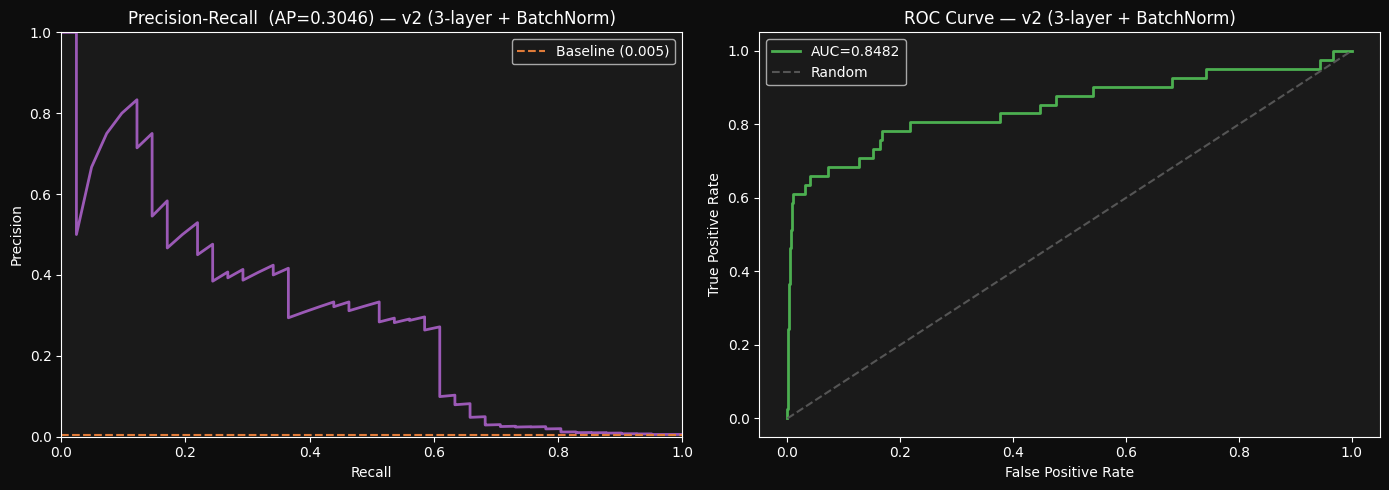

In [16]:
auc_v2, ap_v2 = plot_pr_roc(
    test_y, test_proba_v2, title_suffix="— v2 (3-layer + BatchNorm)", color="#9b59b6"
)

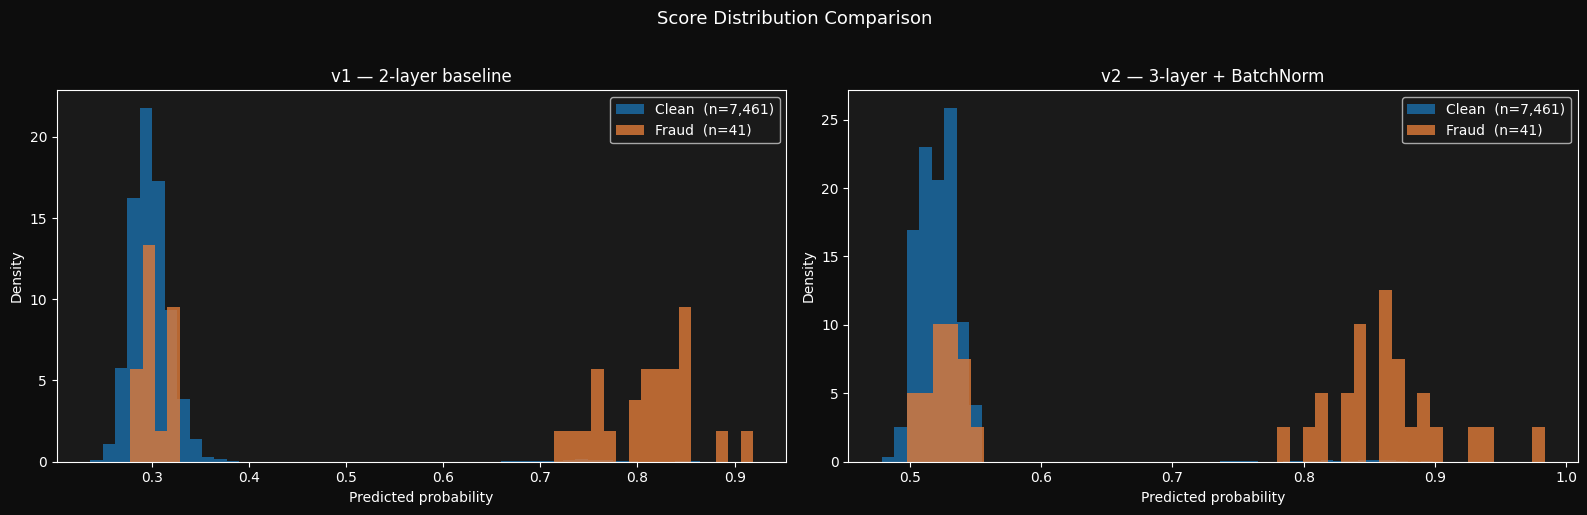

v2 fraud scores — mean: 0.7329  median: 0.8341  min: 0.4981  max: 0.9836
v2 clean scores — mean: 0.5241  median: 0.5214


In [17]:
# Score distribution — v2
fraud_scores_v2 = test_proba_v2[test_y == 1]
clean_scores_v2 = test_proba_v2[test_y == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fraud_s, clean_s, title in [
    (axes[0], fraud_scores_v1, clean_scores_v1, "v1 — 2-layer baseline"),
    (axes[1], fraud_scores_v2, clean_scores_v2, "v2 — 3-layer + BatchNorm"),
]:
    ax.hist(
        clean_s, bins=50, alpha=0.7, color=BLUE, label=f"Clean  (n={len(clean_s):,})", density=True
    )
    ax.hist(
        fraud_s,
        bins=50,
        alpha=0.8,
        color=ORANGE,
        label=f"Fraud  (n={len(fraud_s):,})",
        density=True,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Score Distribution Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(
    "v2 fraud scores —",
    f"mean: {fraud_scores_v2.mean():.4f}  median: {np.median(fraud_scores_v2):.4f}  "
    f"min: {fraud_scores_v2.min():.4f}  max: {fraud_scores_v2.max():.4f}",
)
print(
    "v2 clean scores —",
    f"mean: {clean_scores_v2.mean():.4f}  median: {np.median(clean_scores_v2):.4f}",
)

**What to look for in v2:**
- The bimodal fraud score distribution should be less pronounced — peripheral members
  should shift right (higher scores) as the 3rd layer reaches them.
- The PR curve should collapse at a higher recall threshold (>0.55).
- The model should train for more epochs before early stopping, confirming BatchNorm
  is stabilising gradient flow.

## 9. Hyperparameter Tuning

Grid search over `hidden_dim` × `dropout` × `lr` (18 combinations — `hidden_dim=256` excluded due to VRAM).
All runs logged to MLflow under the `fraud-ring-gnn-tuning` experiment.

In [ ]:
import gc

import torch

# Free GPU memory before tuning — safe to run even after kernel restart
for name in ["data", "model_v1", "model_v2"]:
    obj = globals().get(name)
    if obj is not None:
        try:
            globals()[name] = obj.cpu()
        except Exception:
            pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

In [19]:
# Tuning already complete — display results from saved checkpoints
from pathlib import Path

import pandas as pd
import torch

tuning_dir = Path("models/gnn/artifacts_tuning")
results = []
for run_dir in sorted(tuning_dir.iterdir()):
    ckpt_path = run_dir / "gnn_model.pt"
    if not ckpt_path.exists():
        continue
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    results.append(
        {
            "hidden_dim": ck["hidden_dim"],
            "dropout": ck["dropout"],
            "lr": ck.get("lr", "—"),
            "test_auc": round(ck["test_auc"], 4),
            "test_ap": round(ck["test_ap"], 4),
            "best_epoch": ck["best_epoch"],
        }
    )

df_tuning = pd.DataFrame(results).sort_values("test_auc", ascending=False)
print(df_tuning.to_string(index=False))
print(f"\nBest: AUC={df_tuning.iloc[0]['test_auc']}  dropout={df_tuning.iloc[0]['dropout']}")

 hidden_dim  dropout lr  test_auc  test_ap  best_epoch
         64      0.2  —    0.8622   0.4928          10
         64      0.3  —    0.8452   0.4809           2
         64      0.4  —    0.8388   0.4526          22
         64      0.2  —    0.8109   0.3633           2
         64      0.2  —    0.7882   0.5586         132
         64      0.3  —    0.7842   0.4815          36
         64      0.4  —    0.7821   0.5256         123
         64      0.4  —    0.7683   0.5354          78
         64      0.3  —    0.7641   0.1328          11

Best: AUC=0.8622  dropout=0.2


In [20]:
from pathlib import Path

import torch

tuning_dir = Path("models/gnn/artifacts_tuning")
results = []

for run_dir in sorted(tuning_dir.iterdir()):
    ckpt_path = run_dir / "gnn_model.pt"
    if not ckpt_path.exists():
        continue
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    results.append(
        {
            "run": run_dir.name,
            "hidden_dim": ck["hidden_dim"],
            "dropout": ck["dropout"],
            "test_auc": round(ck["test_auc"], 4),
            "test_ap": round(ck["test_ap"], 4),
            "best_epoch": ck["best_epoch"],
        }
    )

df_results = pd.DataFrame(results).sort_values("test_auc", ascending=False)
print(df_results.to_string(index=False))
print(f"\nBest AUC: {df_results.iloc[0]['test_auc']}  — {df_results.iloc[0]['run']}")

                run  hidden_dim  dropout  test_auc  test_ap  best_epoch
hd64_dr0.2_lr0.0001          64      0.2    0.8622   0.4928          10
 hd64_dr0.3_lr0.001          64      0.3    0.8452   0.4809           2
hd64_dr0.4_lr0.0001          64      0.4    0.8388   0.4526          22
 hd64_dr0.2_lr0.001          64      0.2    0.8109   0.3633           2
hd64_dr0.2_lr0.0005          64      0.2    0.7882   0.5586         132
hd64_dr0.3_lr0.0001          64      0.3    0.7842   0.4815          36
hd64_dr0.4_lr0.0005          64      0.4    0.7821   0.5256         123
 hd64_dr0.4_lr0.001          64      0.4    0.7683   0.5354          78
hd64_dr0.3_lr0.0005          64      0.3    0.7641   0.1328          11

Best AUC: 0.8622  — hd64_dr0.2_lr0.0001


## 10. Final Best Model

Retrain with best hyperparams (`dropout=0.2`, `lr=1e-4`) and `patience=50` to fully exploit the slower convergence.

In [ ]:
import gc

import torch

for name in ["data", "model_v1", "model_v2"]:
    obj = globals().get(name)
    if obj is not None:
        try:
            globals()[name] = obj.cpu()
        except Exception:
            pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

In [22]:
from pathlib import Path

import torch

from models.gnn.train import train as train_gnn

GRAPH_PATH = "data/graphs/hetero_graph.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_gnn(
    graph_path=Path(GRAPH_PATH),
    experiment_name="fraud-ring-gnn-best",
    model_output_dir=Path("models/gnn/artifacts_best"),
    hidden_dim=64,
    dropout=0.2,
    lr=1e-4,
    epochs=500,
    patience=50,
    device_str=DEVICE,
)

🏃 View run gnn-full-batch at: http://localhost:5001/#/experiments/4/runs/38555664d71a4c6bace072fcdc4493df
🧪 View experiment at: http://localhost:5001/#/experiments/4


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import average_precision_score, roc_auc_score

from models.gnn.dataset import load_graph
from models.gnn.model import FraudRingGNN, migrate_state_dict

plt.style.use("dark_background")
matplotlib.rcParams.update(
    {"figure.facecolor": "#0d0d0d", "axes.facecolor": "#1a1a1a", "grid.color": "#333333"}
)
BLUE, ORANGE, GREEN = "#1a7abf", "#e07b39", "#4caf50"

GRAPH_PATH = "data/graphs/hetero_graph.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

data, split = load_graph(GRAPH_PATH, device=DEVICE)
test_mask = split["test"].cpu()
test_y = data["account"].y.cpu()[test_mask].numpy()

ck_best = torch.load(
    "models/gnn/artifacts_best/gnn_model.pt", map_location=DEVICE, weights_only=False
)
model_best = FraudRingGNN(
    hidden_dim=ck_best["hidden_dim"],
    dropout=ck_best["dropout"],
    num_layers=ck_best.get("num_layers", 3),
    use_batchnorm=ck_best.get("use_batchnorm", True),
).to(DEVICE)
model_best.load_state_dict(migrate_state_dict(ck_best["model_state_dict"]))
model_best.eval()

with torch.no_grad():
    proba_best = torch.sigmoid(model_best(data)).cpu().numpy()

test_proba_best = proba_best[test_mask]
auc_best = roc_auc_score(test_y, test_proba_best)
ap_best = average_precision_score(test_y, test_proba_best)

print(f"Best — epoch: {ck_best['best_epoch']}  AUC: {auc_best:.4f}  AP: {ap_best:.4f}")
print()
print("── Full Comparison ─────────────────────────")
print("  v1  (2-layer, no BN)       AUC=0.8379  AP=0.3794")
print("  v2  (3-layer + BN)         AUC=0.8395  AP=0.4107")
print(f"  best (tuned, 3-layer + BN) AUC={auc_best:.4f}  AP={ap_best:.4f}")

precision, recall, _ = precision_recall_curve(test_y, test_proba_best)
fpr, tpr, _ = roc_curve(test_y, test_proba_best)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recall, precision, color="#2ecc71", lw=2)
axes[0].axhline(
    y=test_y.mean(), color=ORANGE, linestyle="--", label=f"Baseline ({test_y.mean():.3f})"
)
axes[0].set_title(f"Precision-Recall  (AP={ap_best:.4f}) — best (tuned)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[1].plot(fpr, tpr, color=GREEN, lw=2, label=f"AUC={auc_best:.4f}")
axes[1].plot([0, 1], [0, 1], color="#555555", linestyle="--", label="Random")
axes[1].set_title("ROC Curve — best (tuned)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()